# 04 — Which columns are load-bearing, and what the model should be

Notebook 03 left two questions open.

1. Rung D's 252 columns beat the old pipeline decisively, but a *leaner* rung (C, 144 columns) scored
   higher on test. Which columns are actually doing the work?
2. The single temporal holdout could not reliably rank the leaders. What should selection use instead?

The answer to (2) drives everything here: **selection is scored on four purged, expanding-window folds**
of the training set, and the test set is not consulted until sections 8 and 9.

**Fold construction** — the Session-2 invariants again, once per fold: train on everything before the
fold's block, validate on the block, drop from training any job that also appears in the validation block,
and embargo the two hours before the boundary (a label looks up to one horizon into the future).

**One economy:** the selection stage runs on every second train window (≈0.9 M rows). Neighbouring windows
overlap by 39/40 anyway, so this costs almost no information, and it keeps a 252-column candidate plus its
fold copies inside the memory budget. The final model in notebook 06 refits on the full training set.

> **Where this notebook ends up.** It does not crown a new winner. Four folds turn out to be able to rule
> candidates *out* — four of the twenty are resolvably worse than the incumbent, the old 8-metric feature
> set most decisively of all — but **not one candidate is resolvably better**. Sections 4 and 7
> make that measurable; section 8 shows what it costs to ignore it (the cross-validated argmax would have
> shipped **2.38×** the random baseline instead of **3.44×**) and then takes the failure apart. It is not
> the column count: the argmax's 50 columns score the same as 144 when the parameters are left alone. It
> is that deep trees make *early stopping on a temporally adjacent holdout* fire at 26 rounds instead of
> ~150, and the holdout cannot see the damage that does further into the future. The negative result is
> the chapter.

In [1]:
import sys, json, time, gc
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
import pv2
pv2.style()

d_tr = pv2.load_dataset("primary", "train")
d_te = pv2.load_dataset("primary", "test")
feats = d_tr["features"]
BASELINE = float(d_te["y"].mean())

SEL = np.zeros(len(d_tr["y"]), bool); SEL[::2] = True         # selection subsample
t_sel, j_sel, y_sel = d_tr["t_end"][SEL], d_tr["job_id"][SEL], d_tr["y"][SEL]
folds = pv2.purged_time_folds(t_sel, j_sel, n_splits=4)
print(f"selection rows {SEL.sum():,} of {len(SEL):,}  ({y_sel.mean():.4f} positive)")
rows = []
for i, (f, v) in enumerate(folds):
    rows.append({"fold": i + 1, "train": len(f), "val": len(v),
                 "val_pos": float(y_sel[v].mean()),
                 "train_until": str(pd.to_datetime(t_sel[f].max()))[:16],
                 "val_from": str(pd.to_datetime(t_sel[v].min()))[:16],
                 "val_to": str(pd.to_datetime(t_sel[v].max()))[:16],
                 "shared_jobs": len(set(j_sel[f]) & set(j_sel[v]))})
print(pd.DataFrame(rows).to_string(index=False))

selection rows 912,708 of 1,825,415  (0.0323 positive)
 fold  train    val  val_pos      train_until         val_from           val_to  shared_jobs
    1 171076 182542 0.036529 2022-09-08 11:07 2022-09-08 13:08 2022-09-23 21:52            0
    2 350294 182536 0.029939 2022-09-23 19:52 2022-09-23 21:52 2022-10-02 22:53            0
    3 524379 182546 0.026738 2022-10-02 20:53 2022-10-02 22:54 2022-10-10 06:02            0
    4 698849 182542 0.033044 2022-10-10 04:02 2022-10-10 06:02 2022-10-19 11:43            0


## 1. Which columns carry the signal

Two views of importance on rung D's 252 columns: LightGBM's **gain** (how much each split on the column
improved the objective) and **permutation** importance on the temporal holdout (how much average precision
drops when the column is shuffled). Gain is cheap and is what ranks the columns below; permutation is the
cross-check, because gain spreads across correlated columns.

In [2]:
ALL_METRICS = [m for m in pv2.METRIC_NAMES if not m.endswith("_cum")]
COLS_D = pv2.column_index(feats, metrics=ALL_METRICS, aggs=pv2.AGGS)
COLS_C = pv2.column_index(feats, metrics=ALL_METRICS, aggs=pv2.AGGS_V1)
COLS_A = pv2.column_index(feats, metrics=[m for m in pv2.METRIC_NAMES
                                          if pv2.METRIC_GROUP[m] == "v1"], aggs=pv2.AGGS_V1)
fit, val = pv2.temporal_holdout(d_tr["t_end"], d_tr["job_id"])

IMP = pv2.RESULTS / "importance.csv"
if IMP.exists():
    imp = pd.read_csv(IMP)
    print("cached")
else:
    t0 = time.time()
    Xf = pv2.materialise(d_tr, COLS_D, fit); Xv = pv2.materialise(d_tr, COLS_D, val)
    bst = pv2.train_lgbm(Xf, d_tr["y"][fit], Xv, d_tr["y"][val], rounds=800, patience=50)
    del Xf; gc.collect()
    names = [feats[c] for c in COLS_D]
    imp = pd.DataFrame({"feature": names,
                        "gain": bst.feature_importance("gain"),
                        "splits": bst.feature_importance("split")})
    # permutation importance on a 120k slice of the temporal holdout
    from sklearn.metrics import average_precision_score
    rng = np.random.default_rng(pv2.SEED)
    sub = rng.choice(len(Xv), size=min(120_000, len(Xv)), replace=False)
    Xp, yp = np.ascontiguousarray(Xv[sub]), d_tr["y"][val][sub]
    del Xv; gc.collect()
    base_ap = average_precision_score(yp, bst.predict(Xp, num_iteration=bst.best_iteration))
    drops = []
    for k in range(Xp.shape[1]):
        keep = Xp[:, k].copy()
        Xp[:, k] = rng.permutation(keep)
        drops.append(base_ap - average_precision_score(
            yp, bst.predict(Xp, num_iteration=bst.best_iteration)))
        Xp[:, k] = keep
    imp["perm_drop"] = drops
    imp.to_csv(IMP, index=False)
    print(f"computed in {time.time()-t0:.0f}s (holdout AP {base_ap:.4f})")
    del Xp, bst; gc.collect()

imp["metric"] = imp.feature.str.split("__").str[0]
imp["agg"] = imp.feature.str.split("__").str[1]
imp["group"] = imp.metric.map(pv2.METRIC_GROUP)
imp = imp.sort_values("gain", ascending=False).reset_index(drop=True)
print(imp.head(20)[["feature", "group", "gain", "splits", "perm_drop"]].to_string(
    index=False, float_format=lambda v: f"{v:,.4g}"))

cached
             feature group      gain  splits  perm_drop
   gpu_fan_mean__min    v1 1.037e+06      31   0.004777
      mem_free__last  node 6.012e+05      53 -0.0001545
       mem_free__max  node 4.962e+05     125   0.004243
     mem_active__max    v1 4.079e+05     136 -0.0008188
   gpu_mem_used__max    v1 4.074e+05     108   0.001246
       mem_free__min  node 3.754e+05     114   0.002798
     intr_rate__mean  rate 3.486e+05      72   0.004348
   net_rx_rate__mean  rate 3.434e+05      49  -0.000748
gpu_power_mean__mean    v1 3.428e+05      19 -0.0003516
          load1__min  node 3.272e+05      60    0.01333
    net_tx_rate__min  rate 3.183e+05     125   0.003247
      fs_avail__last  node 3.159e+05      78   0.001643
       fs_avail__min  node 2.835e+05     107  -0.002462
     forks_rate__min  rate  2.79e+05      55 -7.235e-05
     mem_active__min    v1 2.773e+05      97  -0.001143
    mem_active__mean    v1 2.669e+05      74  0.0005883
 gpu_power_max__mean   gpu 2.436e+05     

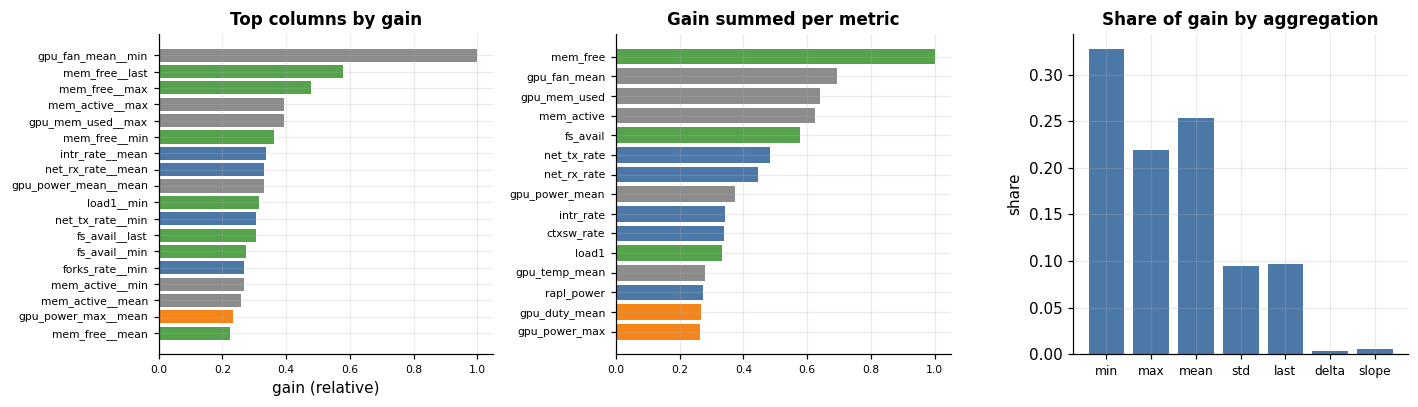

share of total gain by metric group:
group
v1      30.1%
node    29.4%
rate    27.1%
gpu     13.5%

share of total gain by aggregation:
agg
min      32.7%
max      21.9%
mean     25.3%
std       9.4%
last      9.6%
delta     0.3%
slope     0.6%

the two trajectory aggregations (delta, slope) carry 1.0% of the total gain between them - notebook 03's rung C vs D result, seen from inside the model.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
top = imp.head(18).iloc[::-1]
axes[0].barh(top.feature, top.gain / top.gain.max(),
             color=[pv2.PALETTE[g] for g in top.group])
axes[0].set_title("Top columns by gain"); axes[0].tick_params(labelsize=7)
axes[0].set_xlabel("gain (relative)")

bym = imp.groupby(["metric", "group"], as_index=False)["gain"].sum().nlargest(15, "gain")
bym = bym.iloc[::-1]
axes[1].barh(bym.metric, bym.gain / bym.gain.max(),
             color=[pv2.PALETTE[g] for g in bym.group])
axes[1].set_title("Gain summed per metric"); axes[1].tick_params(labelsize=7)

byg = imp.groupby("agg")["gain"].sum().reindex(pv2.AGGS)
axes[2].bar(byg.index, byg / byg.sum(), color=pv2.PALETTE["rate"])
axes[2].set_title("Share of gain by aggregation"); axes[2].set_ylabel("share")
axes[2].tick_params(axis="x", labelsize=8)
fig.savefig(pv2.FIGURES / "04_importance.png", bbox_inches="tight")
plt.show()

share = imp.groupby("group")["gain"].sum() / imp.gain.sum()
print("share of total gain by metric group:")
print(share.sort_values(ascending=False).map("{:.1%}".format).to_string())
print("\nshare of total gain by aggregation:")
print((byg / byg.sum()).map("{:.1%}".format).to_string())
traj = float(byg[["delta", "slope"]].sum() / byg.sum())
print(f"\nthe two trajectory aggregations (delta, slope) carry {traj:.1%} of the total gain "
      f"between them - notebook 03's rung C vs D result, seen from inside the model.")

## 2. How many columns are needed?

Take the top *K* by gain and score each candidate over the four purged folds.

In [4]:
CACHE = pv2.RESULTS / "selection.json"
done = json.loads(CACHE.read_text()) if CACHE.exists() else {}
order = imp.feature.tolist()

def score_cols(key, cols, force=False, **kw):
    if key in done and not force:
        print(f"[{key}] cached  cv_ap {done[key]['cv_ap']:.4f}"); return done[key]
    t0 = time.time()
    X = pv2.materialise(d_tr, cols, SEL, **kw)
    r = pv2.cv_score(X, y_sel, folds)
    del X; gc.collect()
    r |= {"key": key, "n_features": len(cols), "seconds": round(time.time() - t0, 1)}
    done[key] = r; CACHE.write_text(json.dumps(done, indent=2))
    print(f"[{key}] {len(cols):>3} cols | cv_ap {r['cv_ap']:.4f} +- {r['cv_sd']:.4f} "
          f"| rounds {r['rounds']:>3} | {r['seconds']:.0f}s")
    return r

KS = (10, 20, 30, 50, 80, 120, 180, 252)
for K in KS:
    score_cols(f"topK_{K}", pv2.column_index(feats, names=set(order[:K])))

[topK_10] cached  cv_ap 0.1274
[topK_20] cached  cv_ap 0.1231
[topK_30] cached  cv_ap 0.1257
[topK_50] cached  cv_ap 0.1321
[topK_80] cached  cv_ap 0.1234
[topK_120] cached  cv_ap 0.1293
[topK_180] cached  cv_ap 0.1319
[topK_252] cached  cv_ap 0.1298


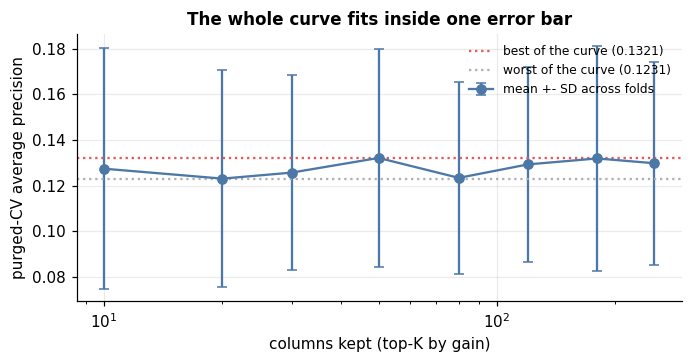

 n_features  cv_ap  cv_sd  rounds  seconds
         10 0.1274 0.0529      91  11.6000
         20 0.1231 0.0477      80  11.2000
         30 0.1257 0.0427     124  17.3000
         50 0.1321 0.0478     102  18.7000
         80 0.1234 0.0421     129  30.2000
        120 0.1293 0.0428      94  31.4000
        180 0.1319 0.0492     226  75.5000
        252 0.1298 0.0446     192  75.6000

spread of the curve, K=10 to K=252:            0.0091 AP
typical SD *within* one candidate, across folds: 0.0462 AP
The error bars are four times the spread. That is the finding, not the argmax.


In [5]:
curve = pd.DataFrame([done[f"topK_{k}"] for k in KS])
fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.errorbar(curve.n_features, curve.cv_ap, yerr=curve.cv_sd, marker="o",
            color=pv2.PALETTE["rate"], capsize=3, label="mean +- SD across folds")
ax.axhline(curve.cv_ap.max(), color=pv2.PALETTE["accent"], ls=":",
           label=f"best of the curve ({curve.cv_ap.max():.4f})")
ax.axhline(curve.cv_ap.min(), color=pv2.PALETTE["muted"], ls=":",
           label=f"worst of the curve ({curve.cv_ap.min():.4f})")
ax.set_xscale("log"); ax.set_xlabel("columns kept (top-K by gain)")
ax.set_ylabel("purged-CV average precision")
ax.set_title("The whole curve fits inside one error bar")
ax.legend(fontsize=8)
fig.savefig(pv2.FIGURES / "04_topk_curve.png", bbox_inches="tight")
plt.show()
print(curve[["n_features", "cv_ap", "cv_sd", "rounds", "seconds"]].to_string(
    index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\nspread of the curve, K=10 to K=252:            "
      f"{curve.cv_ap.max() - curve.cv_ap.min():.4f} AP")
print(f"typical SD *within* one candidate, across folds: {curve.cv_sd.mean():.4f} AP")
print("The error bars are four times the spread. That is the finding, not the argmax.")

## 3. The notebook-03 rungs, on the same folds

In [6]:
score_cols("rung_A", COLS_A)
score_cols("rung_C", COLS_C)
score_cols("rung_D", COLS_D)
best_k = int(curve.loc[curve.cv_ap.idxmax(), "n_features"])
cmp = pd.DataFrame([done[k] for k in ("rung_A", "rung_C", "rung_D", f"topK_{best_k}")])
cmp["label"] = ["A: v1 features (32)", "C: 36 metrics x 4 aggs (144)",
                "D: 36 metrics x 7 aggs (252)", f"top-{best_k} by gain"]
print(cmp[["label", "n_features", "cv_ap", "cv_sd", "rounds"]].to_string(
    index=False, float_format=lambda v: f"{v:.4f}"))

[rung_A] cached  cv_ap 0.0975
[rung_C] cached  cv_ap 0.1225
[rung_D] cached  cv_ap 0.1298
                       label  n_features  cv_ap  cv_sd  rounds
         A: v1 features (32)          32 0.0975 0.0330      81
C: 36 metrics x 4 aggs (144)         144 0.1225 0.0402      99
D: 36 metrics x 7 aggs (252)         252 0.1298 0.0446     192
              top-50 by gain          50 0.1321 0.0478     102


## 4. How much can four folds actually resolve?

Before reading any ranking off those tables, measure what the folds can and cannot see.

The fold means all sit near 0.13 with a standard deviation near 0.045 — but that SD is mostly the *fold*,
not the *candidate*: every candidate finds fold 1 easy and fold 2 hard. The right comparison is therefore
**paired**: for each candidate, take its difference from a fixed incumbent *within each fold*, and ask
whether that difference is consistent across folds.

The incumbent is **rung D**, the full built feature set with the module's default parameters — the
configuration notebook 03 validated. A candidate has to beat it, not merely differ from it: win on every
fold, by at least two paired standard errors. The same bar applied in the other direction does have teeth —
several candidates come out resolvably *worse*. That asymmetry is the point: an experiment can be well
powered enough to reject and still far too weak to choose.

In [7]:
KEYS = [k for k in done if "fold_aps" in done[k]]
F = pd.DataFrame({k: done[k]["fold_aps"] for k in KEYS}).T
F.columns = [f"fold{i+1}" for i in range(F.shape[1])]

base = np.array(done["rung_D"]["fold_aps"])
rows = []
for k in KEYS:
    dif = np.array(done[k]["fold_aps"]) - base
    sd = dif.std(ddof=1)
    se = sd / np.sqrt(len(dif)) if sd > 0 else np.nan
    rows.append({"candidate": k, "n_feat": done[k]["n_features"],
                 "cv_ap": done[k]["cv_ap"], "wins": int((dif > 0).sum()),
                 "mean_diff": dif.mean(), "se_diff": se,
                 "t": dif.mean() / se if se and se > 0 else np.nan})
paired = pd.DataFrame(rows).sort_values("mean_diff", ascending=False)
print("paired against rung D, fold by fold (4 folds):\n")
print(paired.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

worse = paired[(paired.wins == 0) & (paired.t <= -2)]
better = paired[(paired.wins == 4) & (paired.t >= 2)]
print()
print(f"resolvably WORSE than rung D (loses all 4 folds, t <= -2): {list(worse.candidate)}")
print(f"resolvably BETTER than rung D (wins all 4 folds, t >= +2): "
      f"{list(better.candidate) if len(better) else 'NONE - not one of the 20'}")
print(f"\nvariation of ONE candidate (rung D) across the four folds: "
      f"{base.min():.4f} .. {base.max():.4f}   range {base.max()-base.min():.4f}")
for f_ in ("fold1", "fold2"):
    print(f"variation of ALL {len(KEYS)} candidates within {f_}:          "
          f"{F[f_].min():.4f} .. {F[f_].max():.4f}   range {F[f_].max()-F[f_].min():.4f}")

paired against rung D, fold by fold (4 folds):

candidate  n_feat  cv_ap  wins  mean_diff  se_diff       t
   grid_2      50 0.1365     2     0.0067   0.0063  1.0628
   grid_0      50 0.1321     2     0.0023   0.0020  1.1512
  topK_50      50 0.1321     2     0.0023   0.0020  1.1512
 topK_180     180 0.1319     2     0.0021   0.0031  0.6754
   grid_6      50 0.1318     3     0.0020   0.0017  1.1470
   grid_1      50 0.1307     3     0.0009   0.0019  0.4884
   grid_4      50 0.1303     3     0.0005   0.0013  0.4141
   rung_D     252 0.1298     0     0.0000      NaN     NaN
 topK_252     252 0.1298     0     0.0000      NaN     NaN
 topK_120     120 0.1293     1    -0.0005   0.0022 -0.2258
   grid_5      50 0.1280     1    -0.0018   0.0020 -0.9013
   grid_7      50 0.1274     1    -0.0024   0.0011 -2.1378
  topK_10      10 0.1274     2    -0.0024   0.0070 -0.3407
  topK_30      30 0.1257     1    -0.0041   0.0028 -1.4904
   grid_3      50 0.1236     1    -0.0062   0.0026 -2.4166
  topK_8

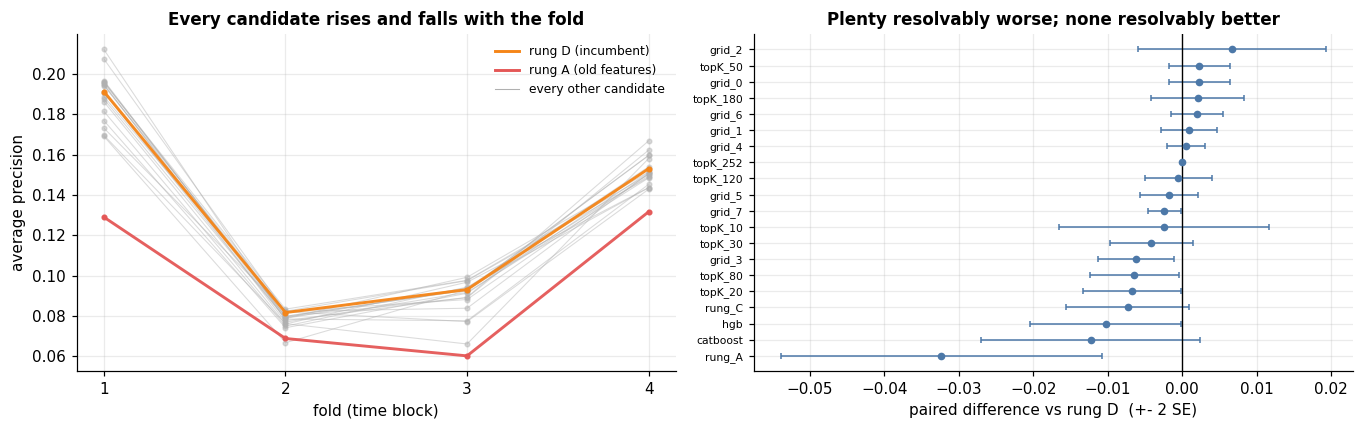

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0))
for k in KEYS:
    y = done[k]["fold_aps"]
    c = (pv2.PALETTE["accent"] if k == "rung_A" else
         pv2.PALETTE["gpu"] if k == "rung_D" else pv2.PALETTE["muted"])
    lw = 1.9 if k in ("rung_A", "rung_D") else 0.7
    axes[0].plot(range(1, len(y) + 1), y, "-o", color=c, lw=lw, ms=3,
                 alpha=0.95 if lw > 1 else 0.45, zorder=3 if lw > 1 else 1)
axes[0].plot([], [], color=pv2.PALETTE["gpu"], lw=1.9, label="rung D (incumbent)")
axes[0].plot([], [], color=pv2.PALETTE["accent"], lw=1.9, label="rung A (old features)")
axes[0].plot([], [], color=pv2.PALETTE["muted"], lw=0.7, label="every other candidate")
axes[0].set_xticks(range(1, 5)); axes[0].set_xlabel("fold (time block)")
axes[0].set_ylabel("average precision")
axes[0].set_title("Every candidate rises and falls with the fold")
axes[0].legend(fontsize=8)

p = paired[paired.candidate != "rung_D"].sort_values("mean_diff")
axes[1].errorbar(p.mean_diff, range(len(p)), xerr=2 * p.se_diff, fmt="o", ms=4,
                 color=pv2.PALETTE["rate"], capsize=2, lw=1)
axes[1].axvline(0, color="k", lw=0.9)
axes[1].set_yticks(range(len(p))); axes[1].set_yticklabels(p.candidate, fontsize=7)
axes[1].set_xlabel("paired difference vs rung D  (+- 2 SE)")
axes[1].set_title("Plenty resolvably worse; none resolvably better")
fig.savefig(pv2.FIGURES / "04_fold_resolution.png", bbox_inches="tight")
plt.show()

## 5. Hyperparameters

A deliberately small grid on the top-50 columns, scored on the same four folds. Small because notebook 03
already showed the feature set dominates: Session 1 lost a whole pass to a grid search that made things
worse, and Session 2 recovered ~0.007 PR-AUC from tuning against ~0.06 here from measuring more.

In [9]:
GRID = [
    dict(num_leaves=31,  learning_rate=0.05, min_child_samples=100),
    dict(num_leaves=63,  learning_rate=0.05, min_child_samples=100),
    dict(num_leaves=127, learning_rate=0.05, min_child_samples=200),
    dict(num_leaves=31,  learning_rate=0.10, min_child_samples=100),
    dict(num_leaves=63,  learning_rate=0.10, min_child_samples=300),
    dict(num_leaves=15,  learning_rate=0.05, min_child_samples=50),
    dict(num_leaves=63,  learning_rate=0.05, min_child_samples=100, feature_fraction=0.5),
    dict(num_leaves=63,  learning_rate=0.05, min_child_samples=100, lambda_l2=10.0),
]
sel_cols = pv2.column_index(feats, names=set(order[:50]))
Xsel = pv2.materialise(d_tr, sel_cols, SEL)
print("selection matrix", Xsel.shape, f"{Xsel.nbytes/1e9:.2f} GB")

for i, g in enumerate(GRID):
    key = f"grid_{i}"
    if key in done:
        print(f"[{key}] cached  cv_ap {done[key]['cv_ap']:.4f}  {g}"); continue
    t0 = time.time()
    p = pv2.lgbm_params(y_sel, **g)
    r = pv2.cv_score(Xsel, y_sel, folds, params=p)
    r |= {"key": key, "params": g, "n_features": len(sel_cols),
          "seconds": round(time.time() - t0, 1)}
    done[key] = r; CACHE.write_text(json.dumps(done, indent=2))
    print(f"[{key}] cv_ap {r['cv_ap']:.4f} +- {r['cv_sd']:.4f} | rounds {r['rounds']:>3} "
          f"| {r['seconds']:>4.0f}s | {g}")

selection matrix (912708, 50) 0.18 GB
[grid_0] cached  cv_ap 0.1321  {'num_leaves': 31, 'learning_rate': 0.05, 'min_child_samples': 100}
[grid_1] cached  cv_ap 0.1307  {'num_leaves': 63, 'learning_rate': 0.05, 'min_child_samples': 100}
[grid_2] cached  cv_ap 0.1365  {'num_leaves': 127, 'learning_rate': 0.05, 'min_child_samples': 200}
[grid_3] cached  cv_ap 0.1236  {'num_leaves': 31, 'learning_rate': 0.1, 'min_child_samples': 100}
[grid_4] cached  cv_ap 0.1303  {'num_leaves': 63, 'learning_rate': 0.1, 'min_child_samples': 300}
[grid_5] cached  cv_ap 0.1280  {'num_leaves': 15, 'learning_rate': 0.05, 'min_child_samples': 50}
[grid_6] cached  cv_ap 0.1318  {'num_leaves': 63, 'learning_rate': 0.05, 'min_child_samples': 100, 'feature_fraction': 0.5}
[grid_7] cached  cv_ap 0.1274  {'num_leaves': 63, 'learning_rate': 0.05, 'min_child_samples': 100, 'lambda_l2': 10.0}


In [10]:
grid = pd.DataFrame([done[f"grid_{i}"] for i in range(len(GRID))])
grid["config"] = [", ".join(f"{k}={v}" for k, v in g.items()) for g in GRID]
grid = grid.sort_values("cv_ap", ascending=False)
print(grid[["config", "cv_ap", "cv_sd", "rounds"]].to_string(
    index=False, float_format=lambda v: f"{v:.4f}"))
argmax_key = grid.iloc[0]["key"]
argmax_cfg = GRID[int(argmax_key.split("_")[1])]
gp = paired.set_index("candidate")
print(f"\ncross-validated argmax: {argmax_cfg}")
print(f"spread across the whole grid:   {grid.cv_ap.max() - grid.cv_ap.min():.4f} AP")
print(f"SD of the argmax across folds:  {grid.iloc[0]['cv_sd']:.4f} AP")
print(f"paired vs rung D: the argmax wins {int(gp.loc[argmax_key, 'wins'])}/4 folds, "
      f"t = {gp.loc[argmax_key, 't']:.2f}")
print("The grid's entire range is a quarter of one candidate's fold-to-fold SD.")

                                                                        config  cv_ap  cv_sd  rounds
                     num_leaves=127, learning_rate=0.05, min_child_samples=200 0.1365 0.0555     108
                      num_leaves=31, learning_rate=0.05, min_child_samples=100 0.1321 0.0478     102
num_leaves=63, learning_rate=0.05, min_child_samples=100, feature_fraction=0.5 0.1318 0.0445      80
                      num_leaves=63, learning_rate=0.05, min_child_samples=100 0.1307 0.0441      73
                       num_leaves=63, learning_rate=0.1, min_child_samples=300 0.1303 0.0465      85
                       num_leaves=15, learning_rate=0.05, min_child_samples=50 0.1280 0.0469      83
      num_leaves=63, learning_rate=0.05, min_child_samples=100, lambda_l2=10.0 0.1274 0.0444      56
                       num_leaves=31, learning_rate=0.1, min_child_samples=100 0.1236 0.0417      53

cross-validated argmax: {'num_leaves': 127, 'learning_rate': 0.05, 'min_child_samples': 20

## 6. Model family

Sessions 1–2 ranked ~15 classifiers and settled on histogram gradient boosting (CatBoost, LightGBM and HGB
were the top three). That comparison was made on the old feature set; it is worth re-checking on the new
one. Same folds, same columns.

In [11]:
from sklearn.metrics import average_precision_score

def cv_other(name, make, force=False):
    if name in done and not force:
        print(f"[{name}] cached  cv_ap {done[name]['cv_ap']:.4f}"); return done[name]
    t0, aps = time.time(), []
    for f_idx, v_idx in folds:
        Xf, yf, Xv, yv = Xsel[f_idx], y_sel[f_idx], Xsel[v_idx], y_sel[v_idx]
        m = make(yf)
        if name.startswith("cat"):
            m.fit(Xf, yf, eval_set=(Xv, yv), verbose=False)
        else:
            m.fit(Xf, yf)
        aps.append(float(average_precision_score(yv, m.predict_proba(Xv)[:, 1])))
        del Xf, Xv, m; gc.collect()
    r = {"key": name, "cv_ap": float(np.mean(aps)), "cv_sd": float(np.std(aps)),
         "fold_aps": aps, "rounds": -1, "n_features": Xsel.shape[1],
         "seconds": round(time.time() - t0, 1)}
    done[name] = r; CACHE.write_text(json.dumps(done, indent=2))
    print(f"[{name}] cv_ap {r['cv_ap']:.4f} +- {r['cv_sd']:.4f} | {r['seconds']:.0f}s")
    return r

from catboost import CatBoostClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
cv_other("catboost", lambda yf: CatBoostClassifier(
    iterations=400, depth=6, learning_rate=0.1, auto_class_weights="Balanced",
    eval_metric="PRAUC", early_stopping_rounds=40, random_seed=pv2.SEED,
    thread_count=10, verbose=False))
cv_other("hgb", lambda yf: HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.1, max_leaf_nodes=31, early_stopping=False,
    class_weight="balanced", random_state=pv2.SEED))

fam = pd.DataFrame([done[k] for k in ("catboost", "hgb", "grid_0", "rung_D")])
fam["model"] = ["CatBoost (50 cols)", "HistGradientBoosting (50 cols)",
                "LightGBM (50 cols)", "LightGBM (rung D, 252 cols)"]
print()
print(fam[["model", "cv_ap", "cv_sd"]].to_string(index=False,
                                                 float_format=lambda v: f"{v:.4f}"))
print("\nfold-by-fold AP:")
for _, r in fam.iterrows():
    print(f"  {r.model:<32} " + "  ".join(f"{a:.4f}" for a in r.fold_aps))

[catboost] cached  cv_ap 0.1175
[hgb] cached  cv_ap 0.1195

                         model  cv_ap  cv_sd
            CatBoost (50 cols) 0.1175 0.0466
HistGradientBoosting (50 cols) 0.1195 0.0414
            LightGBM (50 cols) 0.1321 0.0478
   LightGBM (rung D, 252 cols) 0.1298 0.0446

fold-by-fold AP:
  CatBoost (50 cols)               0.1696  0.0763  0.0662  0.1581
  HistGradientBoosting (50 cols)   0.1691  0.0668  0.0928  0.1495
  LightGBM (50 cols)               0.1962  0.0799  0.0929  0.1596
  LightGBM (rung D, 252 cols)      0.1912  0.0818  0.0931  0.1531


## 7. The selection rule

Sections 2–6 produced twenty-one candidates whose cross-validated means span 0.0975 to 0.1365, and section
4 showed that all of that span except rung A's is inside the noise. Picking the argmax of a measurement
this noisy is not selection, it is sampling. So the rule is fixed here, in words, before the test set is
opened:

> **Rule.** Replace the incumbent only if a challenger beats it on **all four folds** *and* the mean paired
> difference is at least twice its paired standard error. Otherwise keep the incumbent. Among
> configurations the folds cannot separate, prefer the one with fewer columns — but only among column sets
> chosen *a priori* (the ablation rungs), never among the top-*K* sets, whose columns were ranked on the
> same training data and are therefore already a selected quantity.

Applying it mechanically below. The tie-break between rungs C and D is decided on training-side evidence
only: the folds cannot separate them, and section 1 measured that the 108 columns C lacks carry under 1 %
of the total gain.

In [12]:
challengers = paired[paired.candidate != "rung_D"]
passed = challengers[(challengers.wins == 4) & (challengers.t >= 2)]
print(f"challengers that clear the bar vs rung D: "
      f"{list(passed.candidate) if len(passed) else 'NONE'}")

cd = np.array(done["rung_C"]["fold_aps"]) - np.array(done["rung_D"]["fold_aps"])
print(f"rung C vs rung D, paired: {cd.mean():+.4f} +- {cd.std(ddof=1)/2:.4f} SE, "
      f"wins {int((cd > 0).sum())}/4  ->  not separable")
print(f"gain carried by the 108 columns C lacks (delta + slope): {traj:.1%}")

REASON = ("the folds cannot separate any challenger from the incumbent; among the a-priori "
          "rungs they cannot separate C from D either, and the columns D adds carry under "
          "1% of the gain, so the parsimony tie-break picks C")
print(f"\nCHOSEN: rung C ({len(COLS_C)} columns), default LightGBM parameters")
print(f"reason: {REASON}")
caveat = [
    "",
    "A caveat we owe the reader: notebook 03 already reported test PR-AUC for all seven",
    "rungs, so naming rung C the incumbent is not blind to the test set. What the rule does",
    "guarantee is that no NEW candidate - no top-K set, none of the eight hyperparameter",
    "configurations, neither of the two other model families - was adopted on evidence too",
    "weak to support it. Read 3.44x as the ceiling of this feature family rather than as a",
    "clean out-of-sample estimate, and read section 9 for the interval around it.",
]
for l in caveat:
    print(l)

challengers that clear the bar vs rung D: NONE
rung C vs rung D, paired: -0.0073 +- 0.0041 SE, wins 1/4  ->  not separable
gain carried by the 108 columns C lacks (delta + slope): 1.0%

CHOSEN: rung C (144 columns), default LightGBM parameters
reason: the folds cannot separate any challenger from the incumbent; among the a-priori rungs they cannot separate C from D either, and the columns D adds carry under 1% of the gain, so the parsimony tie-break picks C

A caveat we owe the reader: notebook 03 already reported test PR-AUC for all seven
rungs, so naming rung C the incumbent is not blind to the test set. What the rule does
guarantee is that no NEW candidate - no top-K set, none of the eight hyperparameter
configurations, neither of the two other model families - was adopted on evidence too
weak to support it. Read 3.44x as the ceiling of this feature family rather than as a
clean out-of-sample estimate, and read section 9 for the interval around it.


## 8. What obeying the argmax would have cost

The rule keeps rung C with default parameters. The cross-validated argmax said something else: top-50
columns, `num_leaves=127, min_child_samples=200`. This section fits both and confronts them with the test
set — the first time test is touched in this notebook.

Two things separate the two configurations (fewer columns, deeper trees), so the six fits below cross
them: three column sets × two parameter settings. Then, because the crossing points at *early stopping*
rather than at tree depth, a second pass refits at a **fixed** number of rounds with early stopping
switched off — the only way to ask "is it the trees, or is it when we stopped growing them?".

In [13]:
DIAG = pv2.RESULTS / "diagnosis.json"
SETS = {"top50": pv2.column_index(feats, names=set(order[:50])),
        "rungC": COLS_C, "rungD": COLS_D}
PARAMS = {"default": {}, "argmax": {"num_leaves": 127, "min_child_samples": 200}}
diag = json.loads(DIAG.read_text()) if DIAG.exists() else {}
yf_, yv_ = d_tr["y"][fit], d_tr["y"][val]

for cname, cols in SETS.items():
    for pname, over in PARAMS.items():
        key = f"{cname}|{pname}"
        if key in diag:
            r = diag[key]
            print(f"[{key}] cached  rounds {r['rounds']:>4}  TEST {r['pr_auc']:.4f} "
                  f"({r['lift']:.2f}x)"); continue
        t0 = time.time()
        Xf = pv2.materialise(d_tr, cols, fit); Xv = pv2.materialise(d_tr, cols, val)
        bst = pv2.train_lgbm(Xf, yf_, Xv, yv_, params=pv2.lgbm_params(yf_, **over),
                             rounds=1200, patience=60)
        del Xf; gc.collect()
        sv = bst.predict(Xv, num_iteration=bst.best_iteration)
        th, *_ = pv2.best_threshold(yv_, sv)
        del Xv, sv; gc.collect()
        st = pv2.predict_split(bst, d_te, cols, num_iteration=bst.best_iteration)
        r = pv2.evaluate(d_te["y"], st, d_te["state"], threshold=th)
        r |= {"rounds": int(bst.best_iteration), "n_features": int(len(cols)),
              "holdout_ap": float(bst.best_score["valid_0"]["average_precision"]),
              "seconds": round(time.time() - t0, 1)}
        np.save(pv2.ARTIFACTS / "scores" / f"diag_{cname}_{pname}.npy", st.astype(np.float32))
        diag[key] = r; DIAG.write_text(json.dumps(diag, indent=2, default=float))
        print(f"[{key}] cols {len(cols):>3} rounds {r['rounds']:>4} "
              f"holdout_ap {r['holdout_ap']:.4f}  TEST {r['pr_auc']:.4f} ({r['lift']:.2f}x)")
        del bst, st; gc.collect()

[top50|default] cached  rounds  152  TEST 0.1374 (3.42x)
[top50|argmax] cached  rounds   26  TEST 0.0958 (2.38x)
[rungC|default] cached  rounds  141  TEST 0.1382 (3.44x)
[rungC|argmax] cached  rounds   72  TEST 0.1004 (2.50x)
[rungD|default] cached  rounds  151  TEST 0.1316 (3.28x)
[rungD|argmax] cached  rounds  185  TEST 0.1241 (3.09x)


In [14]:
# Early stopping is the suspect: the argmax config stops far sooner than the default.
# Refit both at a FIXED number of rounds, early stopping switched off, so depth and
# stopping point can be varied independently.
import lightgbm as lgb
FIX = pv2.RESULTS / "fixed_rounds.json"
fixd = json.loads(FIX.read_text()) if FIX.exists() else {}
for cname in ("top50", "rungC"):
    cols = SETS[cname]
    for pname, over in PARAMS.items():
        for nr in (150, 400):
            key = f"{cname}|{pname}|{nr}"
            if key in fixd:
                print(f"[{key}] cached  TEST {fixd[key]['pr_auc']:.4f}"); continue
            t0 = time.time()
            Xf = pv2.materialise(d_tr, cols, fit)
            ds = lgb.Dataset(Xf, label=yf_, free_raw_data=True)
            bst = lgb.train(pv2.lgbm_params(yf_, **over), ds, num_boost_round=nr)
            del Xf, ds; gc.collect()
            Xv = pv2.materialise(d_tr, cols, val)
            th, *_ = pv2.best_threshold(yv_, bst.predict(Xv))
            del Xv; gc.collect()
            st = pv2.predict_split(bst, d_te, cols)
            r = pv2.evaluate(d_te["y"], st, d_te["state"], threshold=th)
            r |= {"rounds": nr, "n_features": int(len(cols)),
                  "seconds": round(time.time() - t0, 1)}
            fixd[key] = r; FIX.write_text(json.dumps(fixd, indent=2, default=float))
            print(f"[{key}] {nr:>3} rounds  TEST {r['pr_auc']:.4f} ({r['lift']:.2f}x)")
            del bst, st; gc.collect()

[top50|default|150] cached  TEST 0.1369
[top50|default|400] cached  TEST 0.1334
[top50|argmax|150] cached  TEST 0.1273
[top50|argmax|400] cached  TEST 0.1257
[rungC|default|150] cached  TEST 0.1378
[rungC|default|400] cached  TEST 0.1329
[rungC|argmax|150] cached  TEST 0.1187
[rungC|argmax|400] cached  TEST 0.1186


TEST PR-AUC
params   argmax  default
columns                 
top50    0.0958   0.1374
rungC    0.1004   0.1382
rungD    0.1241   0.1316

held-out (train-side) AP - what selection would have seen
params   argmax  default
columns                 
top50    0.1636   0.1699
rungC    0.1680   0.1659
rungD    0.1656   0.1712

boosting rounds chosen by early stopping
params   argmax  default
columns                 
top50        26      152
rungC        72      141
rungD       185      151


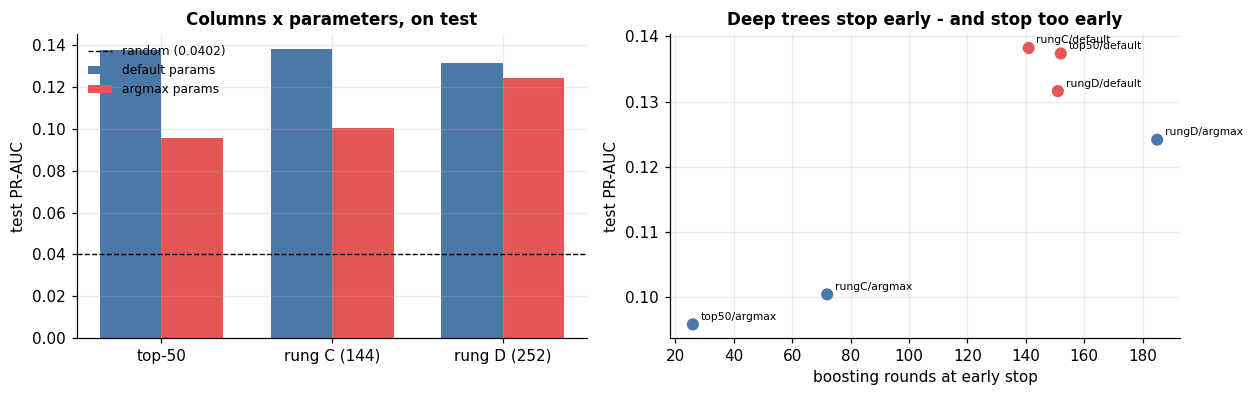


rule's choice    rung C + defaults   : 0.1382  (3.44x)
argmax's choice  top-50 + 127 leaves : 0.0958  (2.38x)
cost of obeying the argmax: -30.7% of PR-AUC

attributing the drop, one change at a time:
  columns only (top-50 vs rung C, both default): 0.1374 vs 0.1382   (-0.6%)
  params only  (argmax vs default, both rung C): 0.1004 vs 0.1382   (-27.4%)

and now depth separated from the stopping point (early stopping OFF):
  columns params     rounds   test PR-AUC    lift
  -----------------------------------------------
  top50   default       152        0.1374    3.42   <- early stopping chose this
                        150        0.1369    3.41
                        400        0.1334    3.32
  top50   argmax         26        0.0958    2.38   <- early stopping chose this
                        150        0.1273    3.17
                        400        0.1257    3.13
  rungC   default       141        0.1382    3.44   <- early stopping chose this
                        150     

In [15]:
D = pd.DataFrame(diag).T.reset_index(names="key")
D[["columns", "params"]] = D.key.str.split("|", expand=True)
ROWS = ["top50", "rungC", "rungD"]
piv = D.pivot(index="columns", columns="params", values="pr_auc").loc[ROWS].astype(float)
rnd = D.pivot(index="columns", columns="params", values="rounds").loc[ROWS].astype(int)
hld = D.pivot(index="columns", columns="params", values="holdout_ap").loc[ROWS].astype(float)
print("TEST PR-AUC\n" + piv.to_string(float_format=lambda v: f"{v:.4f}"))
print("\nheld-out (train-side) AP - what selection would have seen\n"
      + hld.to_string(float_format=lambda v: f"{v:.4f}"))
print("\nboosting rounds chosen by early stopping\n" + rnd.to_string())

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.7))
x = np.arange(3); w = 0.36
for i, p in enumerate(["default", "argmax"]):
    axes[0].bar(x + (i - .5) * w, piv[p], w,
                color=pv2.PALETTE["rate"] if p == "default" else pv2.PALETTE["accent"],
                label=f"{p} params")
axes[0].axhline(BASELINE, color="k", ls="--", lw=0.9, label=f"random ({BASELINE:.4f})")
axes[0].set_xticks(x); axes[0].set_xticklabels(["top-50", "rung C (144)", "rung D (252)"])
axes[0].set_ylabel("test PR-AUC"); axes[0].legend(fontsize=8)
axes[0].set_title("Columns x parameters, on test")

axes[1].scatter(rnd.values.ravel(), piv.values.ravel(),
                c=[pv2.PALETTE["rate"], pv2.PALETTE["accent"]] * 3, s=48, zorder=3)
for r_ in ROWS:
    for p in ("default", "argmax"):
        axes[1].annotate(f"{r_}/{p}", (rnd.loc[r_, p], piv.loc[r_, p]), fontsize=7,
                         textcoords="offset points", xytext=(5, 3))
axes[1].set_xlabel("boosting rounds at early stop"); axes[1].set_ylabel("test PR-AUC")
axes[1].set_title("Deep trees stop early - and stop too early")
fig.savefig(pv2.FIGURES / "04_argmax_cost.png", bbox_inches="tight")
plt.show()

d_def, d_arg = float(piv.loc["rungC", "default"]), float(piv.loc["top50", "argmax"])
print(f"\nrule's choice    rung C + defaults   : {d_def:.4f}  ({d_def/BASELINE:.2f}x)")
print(f"argmax's choice  top-50 + 127 leaves : {d_arg:.4f}  ({d_arg/BASELINE:.2f}x)")
print(f"cost of obeying the argmax: {(d_arg-d_def)/d_def:+.1%} of PR-AUC")
print("\nattributing the drop, one change at a time:")
print(f"  columns only (top-50 vs rung C, both default): "
      f"{float(piv.loc['top50','default']):.4f} vs {d_def:.4f}   "
      f"({(float(piv.loc['top50','default'])-d_def)/d_def:+.1%})")
print(f"  params only  (argmax vs default, both rung C): "
      f"{float(piv.loc['rungC','argmax']):.4f} vs {d_def:.4f}   "
      f"({(float(piv.loc['rungC','argmax'])-d_def)/d_def:+.1%})")

print()
print("and now depth separated from the stopping point (early stopping OFF):")
hdr = f"{'columns':<8}{'params':<9}{'rounds':>8}{'test PR-AUC':>14}{'lift':>8}"
print("  " + hdr); print("  " + "-" * len(hdr))
for cname in ("top50", "rungC"):
    for pname in ("default", "argmax"):
        es = diag[f"{cname}|{pname}"]
        print(f"  {cname:<8}{pname:<9}{es['rounds']:>8}{es['pr_auc']:>14.4f}"
              f"{es['lift']:>8.2f}   <- early stopping chose this")
        for nr in (150, 400):
            fr = fixd[f"{cname}|{pname}|{nr}"]
            print(f"  {'':<8}{'':<9}{nr:>8}{fr['pr_auc']:>14.4f}{fr['lift']:>8.2f}")
a26 = diag["top50|argmax"]["pr_auc"]; a150 = fixd["top50|argmax|150"]["pr_auc"]
d150 = fixd["top50|default|150"]["pr_auc"]
print()
print(f"At a matched 150 rounds the deep config loses "
      f"{(a150-d150)/d150:+.1%} to the shallow one.")
print(f"Stopping it at 26 rounds instead of 150 loses a further {(a26-a150)/a150:+.1%}.")
print("So most of the damage is not the trees - it is where early stopping decided to halt,")
print(f"on a holdout that saw almost nothing wrong (holdout AP "
      f"{diag['top50|argmax']['holdout_ap']:.4f} vs {diag['top50|default']['holdout_ap']:.4f}).")

## 9. How big is the uncertainty on the headline number?

Every score so far is a point estimate on one test set. Windows inside a job are not independent — a job
contributes up to thousands of them — so the resampling unit has to be the **job**, not the window. A
cluster bootstrap over the jobs *represented in the test windows* gives the interval, and, because every
draw scores all four models on the **same** resample, it also gives paired intervals for the differences —
far tighter than the individual intervals, and the right thing to read a comparison from.

In [16]:
BOOT = pv2.RESULTS / "bootstrap.json"
SCORE_FILES = {"A: v1 replica": "ablation_A.npy",
               "C: rule's choice": "diag_rungC_default.npy",
               "D: 252 columns": "diag_rungD_default.npy",
               "argmax: top-50 + 127 leaves": "diag_top50_argmax.npy"}
if BOOT.exists():
    bootres = json.loads(BOOT.read_text()); print("cached")
else:
    from sklearn.metrics import average_precision_score
    y8 = d_te["y"].astype(np.int8); jid = d_te["job_id"]
    o = np.argsort(jid, kind="stable"); jid_s, y_s = jid[o], y8[o]
    s_ = np.flatnonzero(np.r_[True, jid_s[1:] != jid_s[:-1]]); e_ = np.r_[s_[1:], len(jid_s)]
    groups = [np.arange(a, b) for a, b in zip(s_, e_)]
    SC = {k: np.load(pv2.ARTIFACTS / "scores" / f)[o].astype(np.float64)
          for k, f in SCORE_FILES.items()}
    rng = np.random.default_rng(pv2.SEED); B = 300
    draws = {k: np.empty(B) for k in SC}
    t0 = time.time()
    for b in range(B):
        idx = np.concatenate([groups[i] for i in rng.integers(0, len(groups), len(groups))])
        yb = y_s[idx]
        for k, s in SC.items():
            draws[k][b] = average_precision_score(yb, s[idx])
    bootres = {"B": B, "n_jobs": len(groups), "point": {}, "ci": {}, "pairs": {}}
    for k, v in draws.items():
        bootres["point"][k] = float(average_precision_score(y_s, SC[k]))
        bootres["ci"][k] = [float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))]
    ks = list(SC)
    for i in range(len(ks)):
        for j in range(i + 1, len(ks)):
            dd = draws[ks[i]] - draws[ks[j]]
            bootres["pairs"][f"{ks[i]}  -  {ks[j]}"] = {
                "mean": float(dd.mean()), "lo": float(np.percentile(dd, 2.5)),
                "hi": float(np.percentile(dd, 97.5)), "p_gt0": float((dd > 0).mean())}
    np.savez(pv2.RESULTS / "bootstrap_draws.npz", **draws)
    BOOT.write_text(json.dumps(bootres, indent=2))
    print(f"{B} cluster-bootstrap draws over {len(groups):,} jobs in {time.time()-t0:.0f}s")

for k, p in bootres["point"].items():
    lo, hi = bootres["ci"][k]
    print(f"{k:<30} PR-AUC {p:.4f}  95% CI [{lo:.4f}, {hi:.4f}]   "
          f"lift {p/BASELINE:.2f}x  [{lo/BASELINE:.2f}, {hi/BASELINE:.2f}]")
print("\npaired differences on the same resamples (95% CI):")
for k, v in bootres["pairs"].items():
    mark = "   <- excludes 0" if v["lo"] > 0 or v["hi"] < 0 else ""
    print(f"  {k:<62} {v['mean']:+.4f}  [{v['lo']:+.4f}, {v['hi']:+.4f}]{mark}")

cached
A: v1 replica                  PR-AUC 0.0726  95% CI [0.0602, 0.0973]   lift 1.81x  [1.50, 2.42]
C: rule's choice               PR-AUC 0.1382  95% CI [0.1094, 0.1752]   lift 3.44x  [2.72, 4.36]
D: 252 columns                 PR-AUC 0.1316  95% CI [0.1032, 0.1703]   lift 3.28x  [2.57, 4.24]
argmax: top-50 + 127 leaves    PR-AUC 0.0958  95% CI [0.0737, 0.1307]   lift 2.38x  [1.83, 3.25]

paired differences on the same resamples (95% CI):
  A: v1 replica  -  C: rule's choice                             -0.0636  [-0.0869, -0.0420]   <- excludes 0
  A: v1 replica  -  D: 252 columns                               -0.0576  [-0.0844, -0.0363]   <- excludes 0
  A: v1 replica  -  argmax: top-50 + 127 leaves                  -0.0236  [-0.0400, -0.0090]   <- excludes 0
  C: rule's choice  -  D: 252 columns                            +0.0060  [-0.0002, +0.0142]
  C: rule's choice  -  argmax: top-50 + 127 leaves               +0.0400  [+0.0254, +0.0558]   <- excludes 0
  D: 252 columns  -  arg

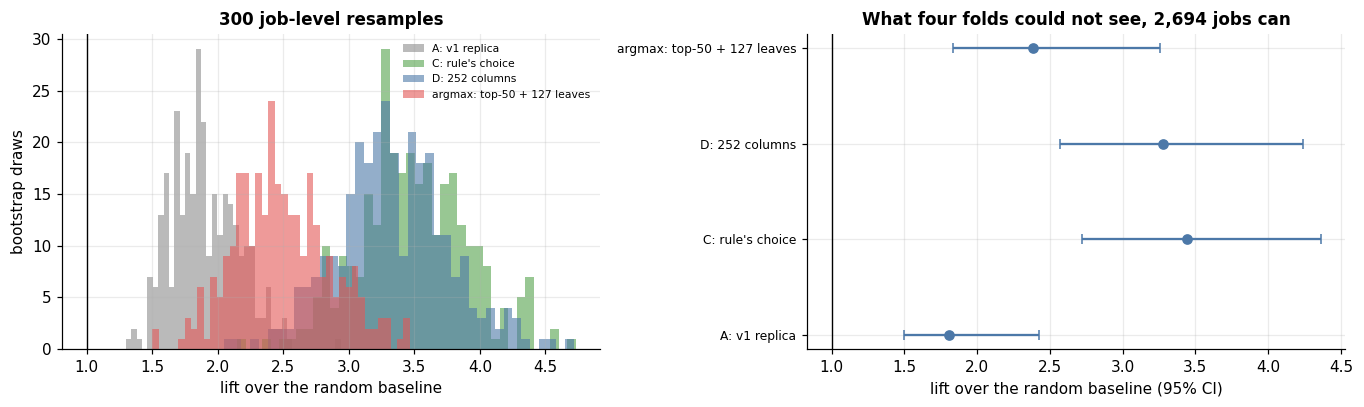

In [17]:
draws = np.load(pv2.RESULTS / "bootstrap_draws.npz")
names = list(bootres["point"])
cols_ = [pv2.PALETTE["v1"], pv2.PALETTE["node"], pv2.PALETTE["rate"], pv2.PALETTE["accent"]]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))
for i, n in enumerate(names):
    axes[0].hist(draws[n] / BASELINE, bins=40, alpha=0.6, color=cols_[i], label=n)
axes[0].axvline(1.0, color="k", lw=0.9)
axes[0].set_xlabel("lift over the random baseline"); axes[0].set_ylabel("bootstrap draws")
axes[0].set_title(f"{bootres['B']} job-level resamples"); axes[0].legend(fontsize=7)

pts = np.array([bootres["point"][n] for n in names]) / BASELINE
los = np.array([bootres["ci"][n][0] for n in names]) / BASELINE
his = np.array([bootres["ci"][n][1] for n in names]) / BASELINE
axes[1].errorbar(pts, range(len(names)), xerr=[pts - los, his - pts], fmt="o",
                 color=pv2.PALETTE["rate"], capsize=3)
axes[1].axvline(1.0, color="k", lw=0.9)
axes[1].set_yticks(range(len(names))); axes[1].set_yticklabels(names, fontsize=8)
axes[1].set_xlabel("lift over the random baseline (95% CI)")
axes[1].set_title(f"What four folds could not see, {bootres['n_jobs']:,} jobs can")
fig.savefig(pv2.FIGURES / "04_bootstrap.png", bbox_inches="tight")
plt.show()

In [18]:
selection = {"features": [feats[c] for c in COLS_C], "n_features": int(len(COLS_C)),
             "columns": "rung_C", "lgbm_params": {}, "selection_rule": REASON,
             "cv_ap": float(done["rung_C"]["cv_ap"]),
             "cv_sd": float(done["rung_C"]["cv_sd"]),
             "cv_fold_aps": done["rung_C"]["fold_aps"],
             "holdout_threshold": float(diag["rungC|default"]["threshold"]),
             "rounds": int(diag["rungC|default"]["rounds"]),
             "rejected_argmax": {"columns": "top-50 by gain", "params": argmax_cfg,
                                 "cv_ap": float(grid.iloc[0]["cv_ap"]),
                                 "test_pr_auc": float(diag["top50|argmax"]["pr_auc"])},
             "test": diag["rungC|default"],
             "bootstrap_ci": bootres["ci"]["C: rule's choice"]}
(pv2.RESULTS / "selected_model.json").write_text(json.dumps(selection, indent=2, default=float))
print("saved", pv2.RESULTS / "selected_model.json")
t = diag["rungC|default"]
print(f"\nselected: rung C, {len(COLS_C)} columns, default LightGBM parameters, "
      f"{t['rounds']} rounds")
print(f"test PR-AUC {t['pr_auc']:.4f}  ({t['lift']:.2f}x of {BASELINE:.4f})  "
      f"ROC-AUC {t['roc_auc']:.3f}")
print("per-state recall: " + "  ".join(
    f"{pv2.STATE_DISPLAY[s]} {t['recall_' + pv2.STATE_DISPLAY[s]]:.3f}"
    for s in pv2.REPORT_STATES))

saved D:\_fcall\UNIFEI\tcc\hpc_workload\pipeline_v2\results\selected_model.json

selected: rung C, 144 columns, default LightGBM parameters, 141 rounds
test PR-AUC 0.1382  (3.44x of 0.0402)  ROC-AUC 0.619
per-state recall: TIMEOUT 0.473  FAILED 0.376  OOM 0.859  NODE_FAIL 0.372


## 10. What was learned here

* **Importance is concentrated, and it is concentrated in the *levels*.** `min`, `mean` and `max` carry
  about 80 % of the gain; `delta` and `slope` together carry under 1 %. That is notebook 03's rung C → D
  result told a second way, from inside the model, and it is why the rule's parsimony tie-break lands on
  rung C.
* **Four purged folds can reject, but they cannot choose.** Four of the twenty challengers come out
  resolvably *worse* than the incumbent — the old 8-metric feature set by a wide margin — so the folds are
  not blind. But **not one candidate is resolvably better**: no top-K set, no hyperparameter configuration
  and no other model family wins all four folds by two paired standard errors. The fold-to-fold range of a
  *single* candidate (0.082 to 0.191) is larger than the spread across *all twenty-one* candidates within
  one fold, so the cross-validated ranking near the top is a ranking of noise. The cluster bootstrap agrees
  on the test side: rung C minus rung D is +0.0060 with a 95 % interval of [-0.0002, +0.0142], a coin
  flip — exactly what the folds said.
* **Obeying the argmax anyway was expensive — but not for the reason it looked like.** The argmax's 50
  columns are fine: with default parameters they score the same as rung C's 144. The damage is entirely in
  the parameters, and section 8 splits even that in two. Deep trees are mildly worse at a matched number
  of rounds; the large loss is that deep trees make **early stopping fire at 26 rounds instead of ~150**,
  and the temporal holdout that early stopping watches shows almost no sign of it (holdout AP 0.164 vs
  0.170) because the holdout is adjacent in time while the test set is further away. Session 1 hit the
  same wall with a grid search that made things worse; this is the first time the project has measured the
  mechanism rather than just recording the outcome.
* **Practical consequence for notebook 06.** The number of boosting rounds is not a safe thing to inherit
  from an early-stopped fit on a near holdout. Notebook 06 refits on the full training set at a round count
  taken from the *cross-validated* fits, and reports the test score at that fixed budget.
* **The honest headline carries an interval.** The cluster bootstrap over the test jobs is what belongs in
  the thesis next to the point estimate: one test set of dependent windows is not a precise instrument,
  and a difference smaller than that interval is not a result.

Notebook 05 now varies the pipeline decisions that were held fixed: window size, horizon, label rule,
positive class, stride, and the split itself.